In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(np.float64(-0.5), np.float64(1725.5), np.float64(969.5), np.float64(-0.5))

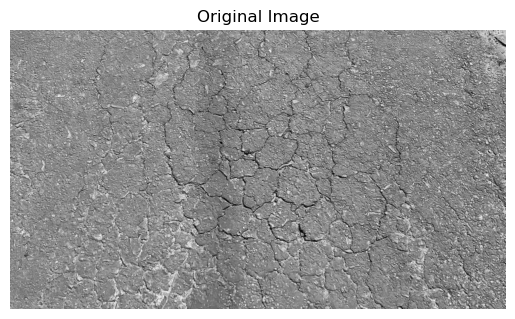

In [3]:
# Load image
image = cv2.imread('C:/Users/sayur/OneDrive/Desktop/Submission_03/data/sample_image.jpg.png', cv2.IMREAD_GRAYSCALE)

# Display original image
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

In [4]:
def noise_reduction(img):
    denoised = cv2.GaussianBlur(img, (5, 5), 0)
    return denoised

(np.float64(-0.5), np.float64(1725.5), np.float64(969.5), np.float64(-0.5))

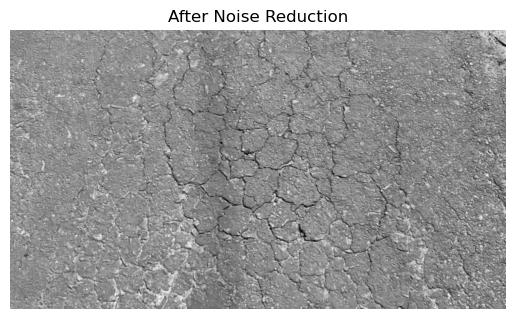

In [5]:
denoised = noise_reduction(image)

plt.imshow(denoised, cmap='gray')
plt.title("After Noise Reduction")
plt.axis('off')

In [6]:
def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(img)
    return clahe_img

(np.float64(-0.5), np.float64(1725.5), np.float64(969.5), np.float64(-0.5))

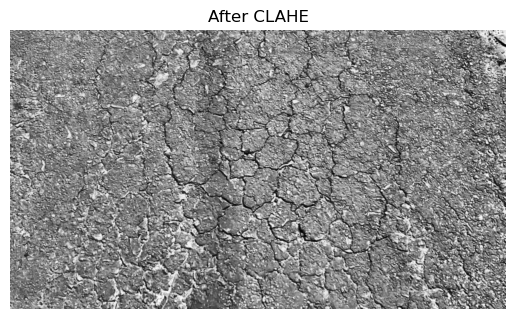

In [7]:
clahe_img = apply_clahe(denoised)

plt.imshow(clahe_img, cmap='gray')
plt.title("After CLAHE")
plt.axis('off')

In [8]:
def sharpen_image(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(img, -1, kernel)
    return sharpened

(np.float64(-0.5), np.float64(1725.5), np.float64(969.5), np.float64(-0.5))

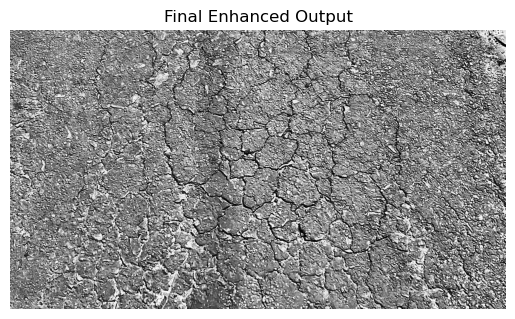

In [9]:
final_output = sharpen_image(clahe_img)

plt.imshow(final_output, cmap='gray')
plt.title("Final Enhanced Output")
plt.axis('off')

In [10]:
def full_pipeline(img):
    step1 = noise_reduction(img)
    step2 = apply_clahe(step1)
    step3 = sharpen_image(step2)
    return step1, step2, step3

In [11]:
nr, cl, final = full_pipeline(image)

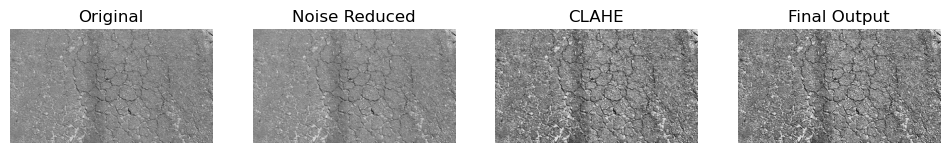

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(nr, cmap='gray')
plt.title("Noise Reduced")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(cl, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(final, cmap='gray')
plt.title("Final Output")
plt.axis('off')

plt.show()

In [13]:
#metric function
def mean_intensity(img):
    return np.mean(img)

def std_contrast(img):
    return np.std(img)

def sharpness(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

In [14]:
#Calculate Metrics
stages = {
    "Original": image,
    "Noise Reduced": nr,
    "CLAHE": cl,
    "Final Output": final
}

results = []

for name, img in stages.items():
    results.append([
        name,
        mean_intensity(img),
        std_contrast(img),
        sharpness(img)
    ])

In [15]:
df = pd.DataFrame(results, columns=[
    "Stage",
    "Mean Intensity",
    "Standard Deviation (Contrast)",
    "Sharpness (Laplacian Variance)"
])

df

,Stage,Mean Intensity,Standard Deviation (Contrast),Sharpness (Laplacian Variance)
0,Original,134.675288,31.642196,1618.471129
1,Noise Reduced,134.676964,23.115367,167.596943
2,CLAHE,130.318637,45.538247,822.296022
3,Final Output,130.194654,66.127691,5917.541223


In [16]:
df.to_csv("tables/final_pipeline_results.csv", index=False)

Final Project Structure

codes/
  01_M1_Noise.ipynb
  02_M2_Illumination.ipynb
  03_M3_Sharpening.ipynb
  04_Full_Pipeline_Integration.ipynb

figures/
  pipeline_flowchart.png
  step_results.png

tables/
  final_pipeline_results.csv

README.md